Objet : TP4_LSTM_OUSSAMA_Ouachou

In [ ]:
import pandas as pd

df = pd.read_csv("test.csv", encoding='latin1')

print(df.head())

       textID                                               text sentiment  \
0  f87dea47db  Last session of the day  http://twitpic.com/67ezh   neutral   
1  96d74cb729   Shanghai is also really exciting (precisely -...  positive   
2  eee518ae67  Recession hit Veronique Branquinho, she has to...  negative   
3  01082688c6                                        happy bday!  positive   
4  33987a8ee5             http://twitpic.com/4w75p - I like it!!  positive   

  Time of Tweet Age of User      Country  Population -2020  Land Area (Km²)  \
0       morning        0-20  Afghanistan        38928346.0         652860.0   
1          noon       21-30      Albania         2877797.0          27400.0   
2         night       31-45      Algeria        43851044.0        2381740.0   
3       morning       46-60      Andorra           77265.0            470.0   
4          noon       60-70       Angola        32866272.0        1246700.0   

   Density (P/Km²)  
0             60.0  
1            1

In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return "" # Handle non-string values, e.g., NaNs
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove special characters, keep letters, numbers and spaces
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

# Filter out rows where 'sentiment' is NaN or 'nan' string
df_cleaned = df.copy()
df_cleaned['sentiment'] = df_cleaned['sentiment'].astype(str) # Ensure sentiment is string type for consistent comparison
df_cleaned = df_cleaned[df_cleaned['sentiment'] != 'nan'].copy() # Remove rows where sentiment is string 'nan'
df_cleaned = df_cleaned.dropna(subset=['sentiment']).copy() # Remove rows where sentiment is actual NaN (should be none after previous step)

display(df_cleaned[['text', 'cleaned_text', 'sentiment']].head())

,text,cleaned_text,sentiment
0,Last session of the day http://twitpic.com/67ezh,last session of the day httptwitpiccom67ezh,neutral
1,Shanghai is also really exciting (precisely -...,shanghai is also really exciting precisely s...,positive
2,"Recession hit Veronique Branquinho, she has to...",recession hit veronique branquinho she has to ...,negative
3,happy bday!,happy bday,positive
4,http://twitpic.com/4w75p - I like it!!,httptwitpiccom4w75p i like it,positive


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_cleaned['cleaned_text'])

sequence = tokenizer.texts_to_sequences(df_cleaned['cleaned_text'])
mots_index = tokenizer.word_index

print(sequence[0])

[82, 1245, 13, 3, 27, 2575]


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Find the maximum sequence length
max_sequence_length = max([len(seq) for seq in sequence])
print(f"Maximum sequence length: {max_sequence_length}")

# Apply padding to uniformize the sequence lengths
padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length, padding='post')

print("Shape of padded sequence:", padded_sequence.shape)
print("First 5 padded sequences:\n", padded_sequence[:5])

Maximum sequence length: 32
Shape of padded sequence: (3534, 32)
First 5 padded sequences:
 [[  82 1245   13    3   27 2575    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [2576   10  259   64  749 2577 2578 2579   28  750   11 1661 2580 2581
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [1662  323 2582 2583  117  107    2 2584   99 1663  312    4  596    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [  55  751    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]
 [2585    1   34    8    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0]]


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Encode the sentiment labels into numerical values
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df_cleaned['sentiment'])

# Split the padded sequences and the numerical labels into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(padded_sequence, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print(f"Encoded sentiment classes: {label_encoder.classes_}")

Shape of X_train: (2827, 32)
Shape of X_test: (707, 32)
Shape of y_train: (2827,)
Shape of y_test: (707,)
Encoded sentiment classes: ['negative' 'neutral' 'positive']


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Defining vocabulary size (number of unique words + 1 for padding)
vocabulary_size = len(mots_index) + 1

# Defining embedding dimension
embedding_dim = 128

# Defining the number of sentiment classes
num_classes = len(label_encoder.classes_)

# Build the model
model = Sequential()
model.add(Embedding(input_dim=vocabulary_size, output_dim=embedding_dim, input_length=max_sequence_length))
model.add(LSTM(units=128))
model.add(Dense(units=num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

print("Model training complete.")

Epoch 1/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.4008 - loss: 1.0907 - val_accuracy: 0.4045 - val_loss: 1.0869
Epoch 2/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.4248 - loss: 1.0589 - val_accuracy: 0.4908 - val_loss: 0.9556
Epoch 3/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - accuracy: 0.5780 - loss: 0.8384 - val_accuracy: 0.5785 - val_loss: 0.9060
Epoch 4/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step - accuracy: 0.7549 - loss: 0.5987 - val_accuracy: 0.5955 - val_loss: 0.9932
Epoch 5/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.8585 - loss: 0.4030 - val_accuracy: 0.6195 - val_loss: 1.1207
Epoch 6/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9130 - loss: 0.2797 - val_accuracy: 0.6181 - val_loss: 1.0394
Epoch 7/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 7s 79ms/step - accuracy: 0.9413 - loss: 0.2033 - val_accuracy: 0.5969 - val_loss: 1.2256
Epoch 8/10
89/89 ━━━━━━━━━━━━━━━━━━━━ 6s 63ms/step - accuracy: 0.9622 - loss: 0.1368 - val_accuracy: 0.5941 - v

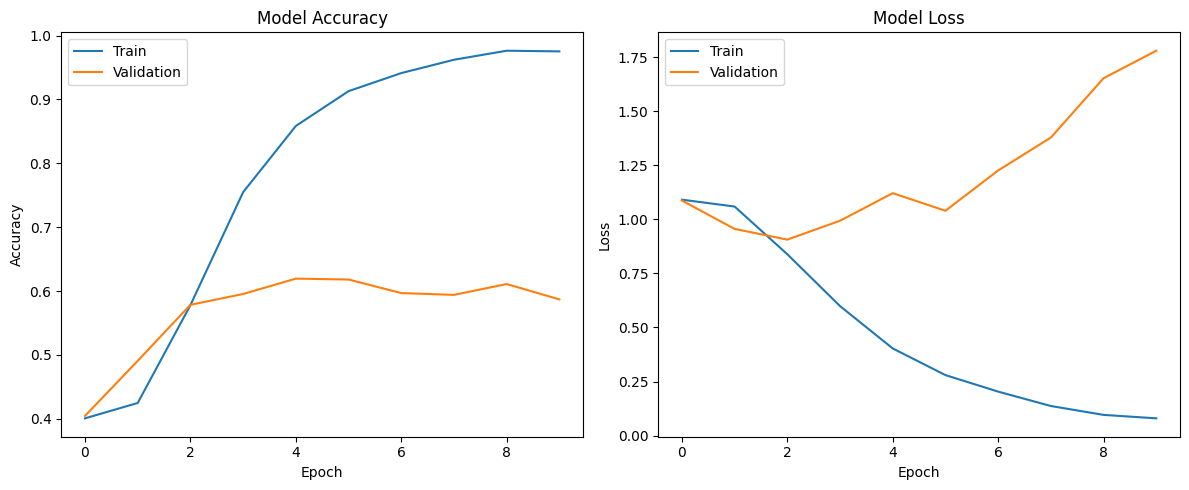

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5870 - loss: 1.7793
Test Loss: 1.7793
Test Accuracy: 0.5870


In [ ]:
def process_sentence(sentence):
    # 1. Clean the text
    cleaned_sentence = clean_text(sentence)

    # 2. Tokenize the cleaned text
    sequence = tokenizer.texts_to_sequences([cleaned_sentence])

    # 3. Pad the sequence
    padded_sequence = pad_sequences(sequence, maxlen=max_sequence_length, padding='post')

    # 4. Predict sentiment using the trained model
    prediction = model.predict(padded_sequence)

    # Get the index of the highest probability class
    predicted_class_index = prediction.argmax(axis=-1)[0]

    # Decode the numerical prediction back to sentiment label
    predicted_sentiment = label_encoder.inverse_transform([predicted_class_index])[0]

    return predicted_sentiment

In [ ]:
# Test with several phrases
test_phrases = [
    "This is a fantastic product, I absolutely love it!",
    "I am so disappointed with the service, it was terrible.",
    "The movie was okay, nothing special.",
    "I feel great today!",
    "This is the worst day ever."
]

print("Sentiment Predictions:")
for phrase in test_phrases:
    sentiment = process_sentence(phrase)
    print(f"Phrase: '{phrase}' -> Predicted Sentiment: '{sentiment}'")

Sentiment Predictions:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
Phrase: 'This is a fantastic product, I absolutely love it!' -> Predicted Sentiment: 'positive'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Phrase: 'I am so disappointed with the service, it was terrible.' -> Predicted Sentiment: 'negative'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Phrase: 'The movie was okay, nothing special.' -> Predicted Sentiment: 'neutral'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Phrase: 'I feel great today!' -> Predicted Sentiment: 'positive'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Phrase: 'This is the worst day ever.' -> Predicted Sentiment: 'negative'
